# Görüntülerde Veri Azaltma - Örnekleme (Sampling) ve Nicemleme (Quantization)

**Biyomedikal bağlam:** Çözünürlük ve bit derinliği; lezyon görünürlüğü, doku kontrastı ve ölçüm doğruluğunu doğrudan etkiler.

> Bu hafta ders akışına göre “Örnekleme ve Nicemleme” konusunu işleyeceğiz.

> Amaç: Görüntüyü **daha az piksel** veya **daha az yoğunluk seviyesi** ile temsil ettiğimizde ne olduğunu görmek ve bunu basit deneylerle yorumlamak.


* Depolama Alanını Azaltmak
Hastanelerde PACS sistemleri bu yüzden sıkıştırma ve veri azaltma teknikleri kullanır.

* İşlem Hızını Artırmak
Yüksek boyut = daha zor optimizasyon problemi, Boyut indirgeme → daha stabil öğrenme

* Veri İletimini Kolaylaştırmak
Tele-tıp, Uzaktan radyoloji vb Bulut sistemlerinde büyük dosyalar gönderilmesi zordur.

* Fazla (Redundant) Bilgiyi Azaltmak

* Gürültüyü Azaltmak

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, transform, util
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

plt.rcParams["figure.figsize"] = (7, 5)


In [15]:
# Örnek görüntüler
img_gray = data.camera()       # uint8, 0-255 (gri seviye)
print("Boyutlar:", img_gray.shape)
print("Veri Tipi:", img_gray.dtype)
print("Veri Değer Aralıkları (min, max):", img_gray.min(), img_gray.max())

Boyutlar: (512, 512)
Veri Tipi: uint8
Veri Değer Aralıkları (min, max): 0 255


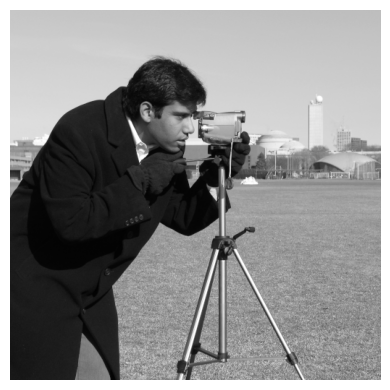

In [19]:
# Görüntüleri görelim
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.imshow(img_gray, cmap="gray")
ax.axis("off")

plt.tight_layout()
plt.show()


# Örnekleme (Sampling) Nedir?
**Örnekleme (sampling)** görüntünün **uzaysal çözünürlüğünü** değiştirir.

**Biyomedikal Alan:**  
MR/BT’de çözünürlük (piksel boyutu, mm/pixel) doku sınırlarını ve ölçümleri etkiler. Aynı matris boyutuna sahip iki görüntü (ör. 512×512) farklı fiziksel alanı temsil edebilir; bu yüzden çözünürlük yalnızca “piksel sayısı” değildir. Aynı zamanda piksellerin taşıdığı bilgidir.



- Piksel sayısını **artırırsak**: Yeni detay “üretilmez”; sadece aradaki pikseller **tahmin edilir** (interpolasyon).


## Downsampling (Küçültme): Piksel Sayısını Azaltma

- Piksel sayısını **azaltırsak**: Detay kaybı olur (küçük lezyonlar kaybolabilir).

Aşağıda aynı görüntüyü farklı boyutlara küçülteceğiz ve detay kaybını gözleyeceğiz.


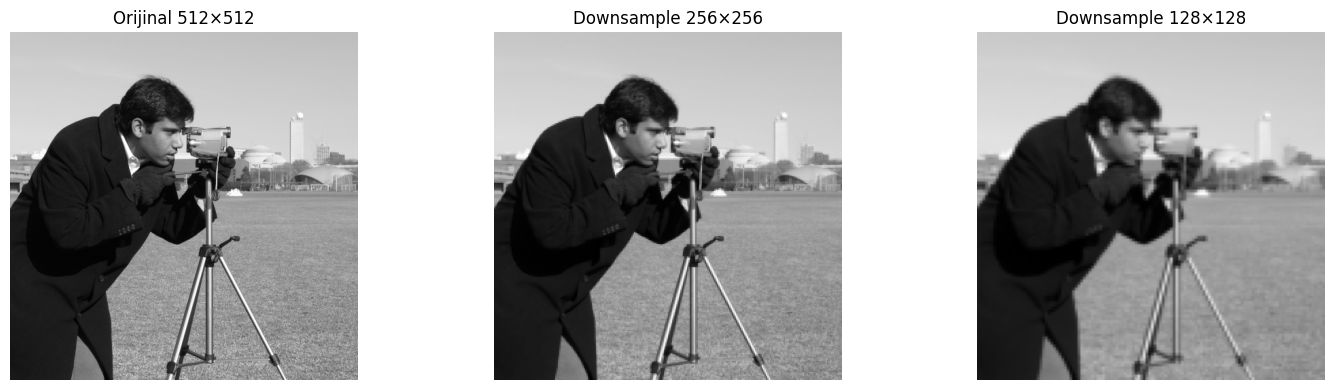

In [20]:
# Küçültme: 512 -> 256 -> 128 (gri seviye)
img_256 = transform.resize(img_gray, (256, 256), anti_aliasing=True)
img_128 = transform.resize(img_gray, (128, 128), anti_aliasing=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(img_gray, cmap="gray"); ax[0].set_title("Orijinal 512×512"); ax[0].axis("off")
ax[1].imshow(img_256, cmap="gray");  ax[1].set_title("Downsample 256×256"); ax[1].axis("off")
ax[2].imshow(img_128, cmap="gray");  ax[2].set_title("Downsample 128×128"); ax[2].axis("off")
plt.tight_layout()
plt.show()


### Anti-Aliasing: Küçültmeden Önce Neden Yumuşatma?
**Aliasing** (örtüşme/yanılsama), görüntüdeki ince detaylar (yüksek frekans) yeni düşük çözünürlükte doğru temsil edilemediğinde ortaya çıkar.

Küçültme işleminde:
- **anti_aliasing=False** → aliasing artefaktları daha belirgin olabilir
- **anti_aliasing=True** → küçültmeden önce yumuşatma uygulanır, aliasing azalır

**Biyomedikal Alan:**  
Küçültme/yeniden örnekleme, özellikle damar yapıları, mikrokalsifikasyonlar gibi ince detaylarda hatalı görünümlere yol açabilir. Anti-aliasing bu riski azaltır.


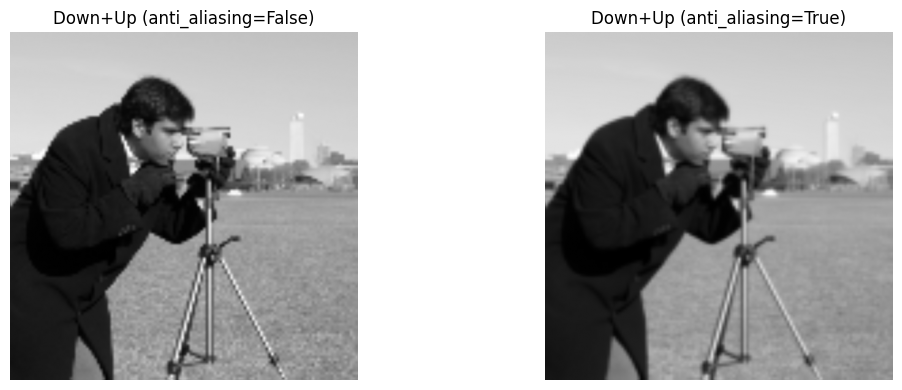

In [21]:
# Aynı küçültmeyi anti_aliasing ile ve olmadan yapalım
down_noaa = transform.resize(img_gray, (128, 128), anti_aliasing=False)
down_aa   = transform.resize(img_gray, (128, 128), anti_aliasing=True)

# Yeniden büyütüp farkı daha görünür yapalım (bilinear)
up_noaa = transform.resize(down_noaa, (512, 512), order=1, anti_aliasing=False)
up_aa   = transform.resize(down_aa,   (512, 512), order=1, anti_aliasing=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(up_noaa, cmap="gray"); ax[0].set_title("Down+Up (anti_aliasing=False)"); ax[0].axis("off")
ax[1].imshow(up_aa,   cmap="gray"); ax[1].set_title("Down+Up (anti_aliasing=True)");  ax[1].axis("off")
plt.tight_layout()
plt.show()


## Upsampling (Büyütme): Interpolation ile Tahmin
Küçülttüğümüz görüntüyü tekrar 512×512 boyutuna büyütelim.  
Bu işlem “detayı geri getirmez”; sadece yeni pikselleri **enterpolasyon** ile hesaplar.

Aşağıda iki basit enterpolasyon göstereceğiz:
- `order=0` → **Nearest Neighbor** (en yakın komşu)
- `order=1` → **Bilinear** (iki doğrusal)


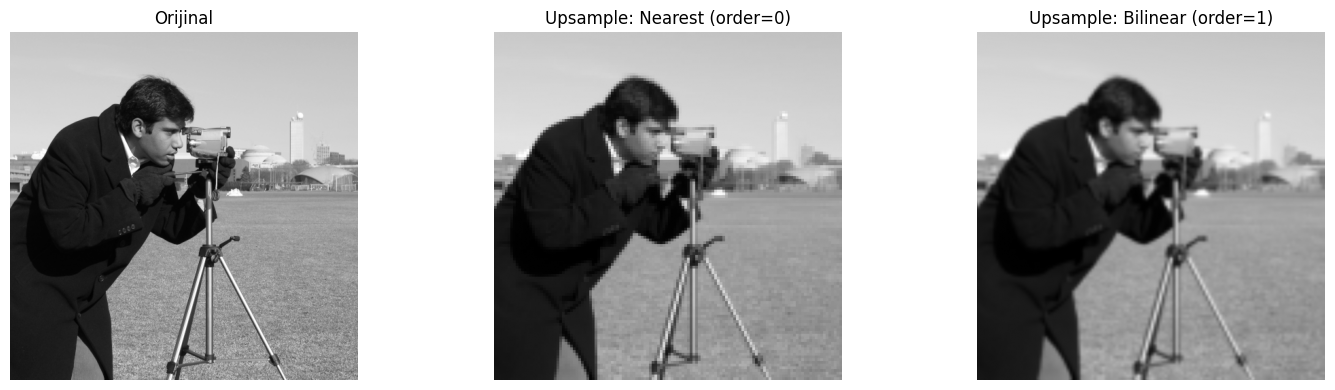

In [22]:
# 128x128'den tekrar 512x512'e büyütme
up_nearest = transform.resize(img_128, (512, 512), order=0, anti_aliasing=False)
up_bilinear = transform.resize(img_128, (512, 512), order=1, anti_aliasing=False)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(img_gray, cmap="gray");     ax[0].set_title("Orijinal"); ax[0].axis("off")
ax[1].imshow(up_nearest, cmap="gray");  ax[1].set_title("Upsample: Nearest (order=0)"); ax[1].axis("off")
ax[2].imshow(up_bilinear, cmap="gray"); ax[2].set_title("Upsample: Bilinear (order=1)"); ax[2].axis("off")
plt.tight_layout()
plt.show()


# Nicemleme (Quantization) Nedir?
**Nicemleme (quantization)**, piksel yoğunluk değerlerini daha az sayıda seviyeye indirger.

- 8-bit → 256 seviye (0–255)
- 4-bit → 16 seviye
- 2-bit → 4 seviye

**Ne olur?**
- İnce yoğunluk geçişleri kaybolur
- **Banding (bantlaşma)** görülebilir

**Biyomedikal Alan:**  
Düşük bit derinliği, yumuşak doku kontrastını azaltabilir ve lezyon–doku ayrımını zorlaştırabilir.


## Basit 4-bit Nicemleme (16 seviye)
Aşağıda `uint8` bir görüntüyü 16 seviyeye indiriyoruz.  
Dikkat: Bu, banding etkisini gözlemlemek için “bilerek bilgi kaybettirdiğimiz” bir deneydir.


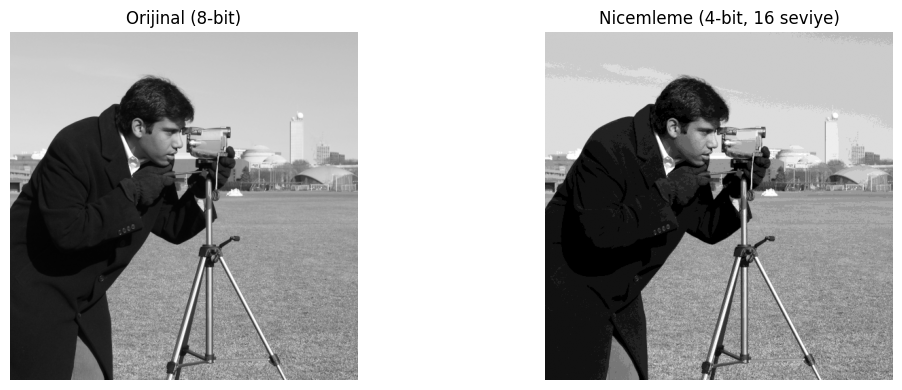

In [7]:
# 4-bit nicemleme: 16 seviye
levels = 16
step = 256 // levels  # 16

# Basit nicemleme (fonksiyonsuz, adım adım)
q4 = (img_gray // step) * step
q4 = q4.astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(img_gray, cmap="gray"); ax[0].set_title("Orijinal (8-bit)"); ax[0].axis("off")
ax[1].imshow(q4, cmap="gray");       ax[1].set_title("Nicemleme (4-bit, 16 seviye)"); ax[1].axis("off")
plt.tight_layout()
plt.show()


## Histogram Üzerinde Nicemleme Etkisi
Nicemlemeden sonra histogram “basamaklı” görünmeye başlar. Çünkü artık az sayıda yoğunluk seviyesi vardır.


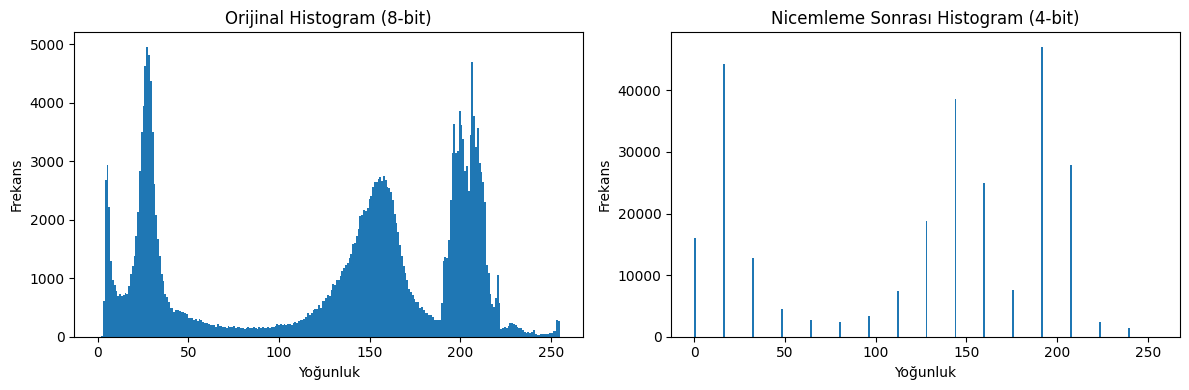

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(img_gray.flatten(), bins=256, range=(0,255))
ax[0].set_title("Orijinal Histogram (8-bit)")
ax[0].set_xlabel("Yoğunluk"); ax[0].set_ylabel("Frekans")

ax[1].hist(q4.flatten(), bins=256, range=(0,255))
ax[1].set_title("Nicemleme Sonrası Histogram (4-bit)")
ax[1].set_xlabel("Yoğunluk"); ax[1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()


# 4) Banding’i Azaltma Fikri: Dithering (Floyd–Steinberg)
**Dithering**, nicemleme hatasını komşu piksellere dağıtarak banding’i azaltmaya çalışır.  
Bu, “bilgi kaybını yok etmek” değil; kaybın **görsel etkisini yönetmek** demektir.



Dithering, sınırlı renk veya gri seviye sayısına sahip bir görüntüde, daha fazla ton varmış gibi bir algı oluşturmak için kullanılan bir tekniktir.

Özellikle:

* 8-bit → 1-bit (siyah-beyaz) dönüşümünde

* Düşük renkli ekranlarda

* Eski yazıcı ve baskı sistemlerinde

* Tıbbi görüntülerin düşük bit derinlikli gösteriminde

kullanılır.

En bilinen yöntemlerden biri Floyd–Steinberg dithering algoritmasıdır.

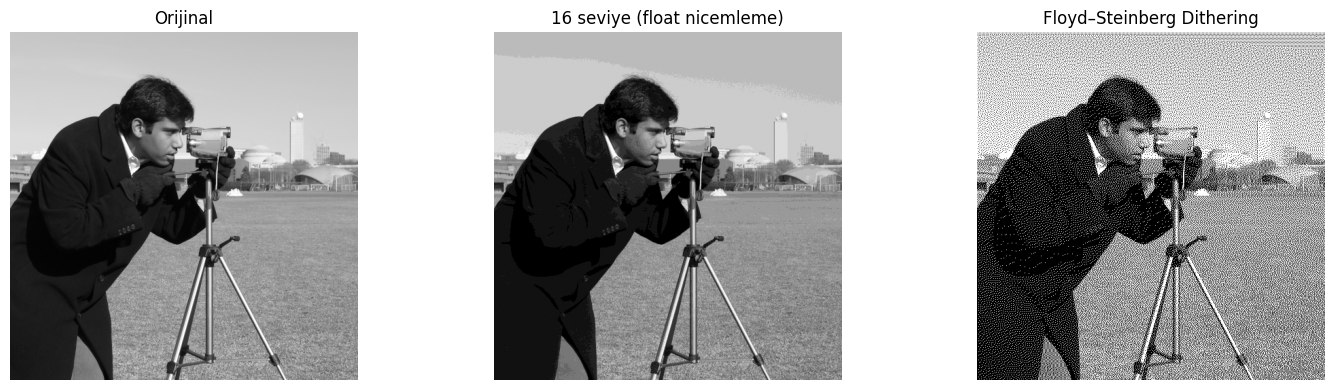

In [9]:
# Dithering için önce görüntüyü float [0,1] aralığına alalım (sadece hesap için)
img_f = util.img_as_float(img_gray)

# Nicemleme: 16 seviyeye indir (float üzerinde)
levels = 16
q_float = np.floor(img_f * (levels - 1)) / (levels - 1)

# Floyd–Steinberg dithering (Pillow kütüphanesi ile) - skimage'de doğrudan kaldırıldı
from PIL import Image

# Görüntüyü 0-255 aralığına geri alıp PIL Image'e dönüştür
pil_img = Image.fromarray(util.img_as_ubyte(img_f))

# 1-bit (binary) dithering için convert("1") kullan, Floyd-Steinberg algoritması ile
dithered_pil = pil_img.convert("1", dither=Image.Dither.FLOYDSTEINBERG)

# PIL Image'i tekrar numpy array'e çevir
dithered = np.array(dithered_pil)

# Görselleştirelim
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(img_gray, cmap="gray"); ax[0].set_title("Orijinal"); ax[0].axis("off")
ax[1].imshow(q_float, cmap="gray");  ax[1].set_title("16 seviye (float nicemleme)"); ax[1].axis("off")
ax[2].imshow(dithered, cmap="gray"); ax[2].set_title("Floyd–Steinberg Dithering"); ax[2].axis("off")
plt.tight_layout()
plt.show()

📌 Biyomedikal not: Dithering, bazı görüntüleme/ekranlama süreçlerinde görsel algıyı iyileştirir;  
ancak nicel ölçüm yapılacaksa (ör. yoğunluğa dayalı doku analizi) dikkatli kullanmak gerekir.


# “Gözle” Değil “Sayıyla” Karşılaştırma: PSNR ve SSIM

Sampling ve quantization sonrası kaliteyi sadece görsel olarak değil, metriklerle de değerlendirebiliriz.

- **PSNR**: Gürültü/bozulma seviyesini (genelde) ölçer (yüksek daha iyi)
- **SSIM**: Yapısal benzerliği ölçer (1’e yakın daha iyi)

> Biyomedikal görüntülerde (özellikle ölçüm/segmentasyon öncesi), bu tür metrikler kaliteyi nicel olarak takip etmek için kullanılabilir.


## Down+Up sonrası PSNR/SSIM
Aşağıda:
- 512→128→512 (anti_aliasing=False)
- 512→128→512 (anti_aliasing=True)

sonuçlarını orijinal ile karşılaştıracağız.


In [24]:
# Metrikler için aynı aralıkta (float) çalışmak daha sağlıklı
orig = util.img_as_float(img_gray)

# up_noaa ve up_aa zaten float üretmişti
psnr_noaa = peak_signal_noise_ratio(orig, up_noaa, data_range=1.0)
ssim_noaa = structural_similarity(orig, up_noaa, data_range=1.0)

psnr_aa = peak_signal_noise_ratio(orig, up_aa, data_range=1.0)
ssim_aa = structural_similarity(orig, up_aa, data_range=1.0)

print("Down+Up anti_aliasing=False  -> PSNR:", round(psnr_noaa, 3), " SSIM:", round(ssim_noaa, 4))
print("Down+Up anti_aliasing=True   -> PSNR:", round(psnr_aa, 3),   " SSIM:", round(ssim_aa, 4))


Down+Up anti_aliasing=False  -> PSNR: 25.758  SSIM: 0.7581
Down+Up anti_aliasing=True   -> PSNR: 25.213  SSIM: 0.7295


## 5.2) Nicemleme sonrası PSNR/SSIM
Orijinal (8-bit) ile 4-bit nicemlenmiş görüntüyü kıyaslayalım.


In [26]:
# q4 uint8; metrik için float'a alalım
q4_f = util.img_as_float(q4)

psnr_q4 = peak_signal_noise_ratio(orig, q4_f, data_range=1.0)
ssim_q4 = structural_similarity(orig, q4_f, data_range=1.0)

print("4-bit nicemleme -> PSNR:", round(psnr_q4, 3), " SSIM:", round(ssim_q4, 4))


4-bit nicemleme -> PSNR: 29.216  SSIM: 0.8847


# Kapanış: 3. Hafta Özet

Bu hafta iki farklı “veri azaltma” türünü gördük:

1. **Sampling**: Piksel sayısını değiştirir (uzaysal çözünürlük).
2. **Quantization**: Yoğunluk seviyesini değiştirir (bit derinliği).

Ek modüller:
- **Anti-aliasing**: küçültmede aliasing’i azaltır.
- **Dithering**: nicemlemenin görsel banding etkisini azaltmaya çalışır.
- **PSNR/SSIM**: bozulmayı sayısallaştırır.

**Biyomedikal mesaj:**  
Çözünürlük ve bit derinliği, görüntüdeki klinik detayların seçilebilirliğini etkiler. Bu nedenle “daha küçük dosya” her zaman “daha iyi” demek değildir.